# Hledání optimálního modelu pro časovou řadu počtu přenocování turistů v České republice

## I - Grafická analýza hlavní časové řady

In [1]:
!pip install eurostat pandas numpy matplotlib statsmodels scipy pmdarima

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import eurostat

In [3]:
dataset_codes = ["tour_occ_nim", "tour_occ_arm"]

for code in dataset_codes:
    print("\nDATASET:", code)
    print("Parameters:", eurostat.get_pars(code))


DATASET: tour_occ_nim
Parameters: ['freq', 'c_resid', 'unit', 'nace_r2', 'geo']

DATASET: tour_occ_arm
Parameters: ['freq', 'c_resid', 'unit', 'nace_r2', 'geo']


In [4]:
for code in dataset_codes:
    print("\n==============================")
    print("DATASET:", code)
    print("==============================")

    for par in eurostat.get_pars(code):
        values = eurostat.get_par_values(code, par)
        print(f"\n{par}:")
        print(values[:30])
        print("count:", len(values))


DATASET: tour_occ_nim

freq:
['M']
count: 1

c_resid:
['DOM', 'FOR', 'TOTAL']
count: 3

unit:
['NR', 'PCH_SM', 'PCH_SM_2Y', 'PCH_SM_19']
count: 4

nace_r2:
['I551-I553', 'I551', 'I552_I553', 'I552', 'I553']
count: 5

geo:
['EU27_2020', 'EU28', 'EU27_2007', 'EU25', 'EA', 'EA20', 'EA19', 'BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO']
count: 45

DATASET: tour_occ_arm

freq:
['M']
count: 1

c_resid:
['DOM', 'FOR', 'TOTAL']
count: 3

unit:
['NR', 'PCH_SM', 'PCH_SM_2Y', 'PCH_SM_19']
count: 4

nace_r2:
['I551-I553', 'I551', 'I552_I553', 'I552', 'I553']
count: 5

geo:
['EU27_2020', 'EU28', 'EU27_2007', 'EU25', 'EA', 'EA20', 'EA19', 'BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO']
count: 45


In [5]:
countries = ["CZ", "DE", "AT", "SK", "PL"]

common_filter = {
    "freq": "M",
    "geo": countries,
    "unit": "NR",
    "c_resid": ["TOTAL", "DOM", "FOR"],
    "startPeriod": "2013-01"
}

nights_filter = {
    **common_filter,
    "nace_r2": "I551-I553"
}

arrivals_filter = {
    **common_filter,
    "nace_r2": "I551-I553"
}

nights_raw = eurostat.get_data_df(
    "tour_occ_nim",
    flags=False,
    filter_pars=nights_filter,
    verbose=True
)

arrivals_raw = eurostat.get_data_df(
    "tour_occ_arm",
    flags=False,
    filter_pars=arrivals_filter,
    verbose=True
)

print("Nights shape:", nights_raw.shape)
print("Arrivals shape:", arrivals_raw.shape)

display(nights_raw.head())
display(arrivals_raw.head())

print("Nights columns:")
print(nights_raw.columns)

print("Arrivals columns:")
print(arrivals_raw.columns)

Download progress: 100.0%

Download progress: 100.0%

Nights shape: (15, 164)
Arrivals shape: (15, 164)


,freq,c_resid,unit,nace_r2,geo\TIME_PERIOD,2013-01,2013-02,2013-03,2013-04,2013-05,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
0,M,TOTAL,NR,I551-I553,CZ,2555690.0,2876204.0,3166229.0,2933205.0,3828516.0,...,5554600.0,7855902.0,8187688.0,5216615.0,4686713.0,3669374.0,3886275.0,3526405.0,3982545.0,None
1,M,DOM,NR,I551-I553,CZ,1257521.0,1596083.0,1413622.0,1131023.0,1618581.0,...,3168940.0,5142422.0,5238637.0,2882300.0,2272701.0,1798216.0,1449215.0,1834671.0,2154877.0,None
2,M,FOR,NR,I551-I553,CZ,1298169.0,1280121.0,1752607.0,1802182.0,2209935.0,...,2385660.0,2713480.0,2949051.0,2334315.0,2414012.0,1871158.0,2437060.0,1691734.0,1827668.0,None
3,M,TOTAL,NR,I551-I553,DE,17522839.0,19109161.0,23680421.0,25070918.0,34737611.0,...,45529826.0,51582611.0,54474663.0,43492866.0,40614764.0,27295991.0,27906325.0,21241104.0,23285429.0,None
4,M,DOM,NR,I551-I553,DE,13771762.0,14898936.0,19019224.0,19737469.0,28471170.0,...,37998862.0,41223815.0,44785512.0,35818549.0,33419671.0,21705259.0,21323353.0,16963901.0,18207151.0,None


,freq,c_resid,unit,nace_r2,geo\TIME_PERIOD,2013-01,2013-02,2013-03,2013-04,2013-05,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
0,M,TOTAL,NR,I551-I553,CZ,852860.0,923105.0,1120874.0,1095459.0,1434115.0,...,2367931.0,2709636.0,2972902.0,2171366.0,1974786.0,1590785.0,1636658.0,1423900.0,1471205.0,None
1,M,DOM,NR,I551-I553,CZ,450899.0,520671.0,524115.0,466316.0,628888.0,...,1336322.0,1608456.0,1769303.0,1208435.0,993718.0,822431.0,666211.0,755376.0,794489.0,None
2,M,FOR,NR,I551-I553,CZ,401961.0,402434.0,596759.0,629143.0,805227.0,...,1031609.0,1101180.0,1203599.0,962931.0,981068.0,768354.0,970447.0,668524.0,676716.0,None
3,M,TOTAL,NR,I551-I553,DE,7955403.0,8670424.0,10555553.0,11446166.0,14537832.0,...,18807029.0,19854832.0,20207897.0,18153686.0,17210839.0,13324541.0,13155984.0,9938948.0,10899215.0,None
4,M,DOM,NR,I551-I553,DE,6287043.0,6818611.0,8466313.0,9010946.0,11733841.0,...,15359594.0,15188682.0,15978285.0,14702543.0,14038989.0,10774156.0,10110799.0,7999992.0,8627522.0,None


Nights columns:
Index(['freq', 'c_resid', 'unit', 'nace_r2', 'geo\TIME_PERIOD', '2013-01',
       '2013-02', '2013-03', '2013-04', '2013-05',
       ...
       '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11',
       '2025-12', '2026-01', '2026-02', '2026-03'],
      dtype='object', length=164)
Arrivals columns:
Index(['freq', 'c_resid', 'unit', 'nace_r2', 'geo\TIME_PERIOD', '2013-01',
       '2013-02', '2013-03', '2013-04', '2013-05',
       ...
       '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11',
       '2025-12', '2026-01', '2026-02', '2026-03'],
      dtype='object', length=164)


In [6]:
import re

def eurostat_wide_to_long(df, value_name):
    """
    Converts Eurostat wide format to long format.

    Input:
        freq | c_resid | unit | nace_r2 | geo\\TIME_PERIOD | 2013-01 | 2013-02 | ...

    Output:
        freq | c_resid | unit | nace_r2 | geo | date | value_name
    """
    df = df.copy()

    # Eurostat column may be called something like 'geo\\TIME_PERIOD'
    geo_col = [col for col in df.columns if str(col).startswith("geo")][0]
    df = df.rename(columns={geo_col: "geo"})

    # Monthly columns: 2013-01, 2013-02, ...
    date_cols = [
        col for col in df.columns
        if re.match(r"^\d{4}-\d{2}$", str(col))
    ]

    id_vars = [col for col in df.columns if col not in date_cols]

    long_df = df.melt(
        id_vars=id_vars,
        value_vars=date_cols,
        var_name="date",
        value_name=value_name
    )

    long_df["date"] = pd.to_datetime(long_df["date"])
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")

    return long_df


nights_long = eurostat_wide_to_long(nights_raw, "nights")
arrivals_long = eurostat_wide_to_long(arrivals_raw, "arrivals")

display(nights_long.head())
display(arrivals_long.head())

print("Nights long shape:", nights_long.shape)
print("Arrivals long shape:", arrivals_long.shape)

,freq,c_resid,unit,nace_r2,geo,date,nights
0,M,TOTAL,NR,I551-I553,CZ,2013-01-01,2555690.0
1,M,DOM,NR,I551-I553,CZ,2013-01-01,1257521.0
2,M,FOR,NR,I551-I553,CZ,2013-01-01,1298169.0
3,M,TOTAL,NR,I551-I553,DE,2013-01-01,17522839.0
4,M,DOM,NR,I551-I553,DE,2013-01-01,13771762.0


,freq,c_resid,unit,nace_r2,geo,date,arrivals
0,M,TOTAL,NR,I551-I553,CZ,2013-01-01,852860.0
1,M,DOM,NR,I551-I553,CZ,2013-01-01,450899.0
2,M,FOR,NR,I551-I553,CZ,2013-01-01,401961.0
3,M,TOTAL,NR,I551-I553,DE,2013-01-01,7955403.0
4,M,DOM,NR,I551-I553,DE,2013-01-01,6287043.0


Nights long shape: (2385, 7)
Arrivals long shape: (2385, 7)


In [7]:
def make_pivot_table(long_df, value_col, prefix):
    """
    Creates columns like:
    nights_CZ_total
    nights_CZ_dom
    nights_CZ_for
    """
    pivot = long_df.pivot_table(
        index="date",
        columns=["geo", "c_resid"],
        values=value_col,
        aggfunc="first"
    )

    pivot.columns = [
        f"{prefix}_{geo}_{resid.lower()}"
        for geo, resid in pivot.columns
    ]

    pivot = pivot.sort_index()
    return pivot


nights_pivot = make_pivot_table(nights_long, "nights", "nights")
arrivals_pivot = make_pivot_table(arrivals_long, "arrivals", "arrivals")

data = pd.concat([nights_pivot, arrivals_pivot], axis=1)

# Monthly start frequency
data = data.asfreq("MS")

display(data.head())
display(data.tail())

print("Final data shape:", data.shape)
print(data.columns.tolist())

,nights_AT_dom,nights_AT_for,nights_AT_total,nights_CZ_dom,nights_CZ_for,nights_CZ_total,nights_DE_dom,nights_DE_for,nights_DE_total,nights_PL_dom,...,arrivals_CZ_total,arrivals_DE_dom,arrivals_DE_for,arrivals_DE_total,arrivals_PL_dom,arrivals_PL_for,arrivals_PL_total,arrivals_SK_dom,arrivals_SK_for,arrivals_SK_total
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,2404241.0,9019010.0,11423251.0,1257521.0,1298169.0,2555690.0,13771762.0,3751077.0,17522839.0,2817874.0,...,852860.0,6287043.0,1668360.0,7955403.0,1083432.0,269077.0,1352509.0,147663.0,105083.0,252746.0
2013-02-01,2953399.0,9996447.0,12949846.0,1596083.0,1280121.0,2876204.0,14898936.0,4210225.0,19109161.0,3044222.0,...,923105.0,6818611.0,1851813.0,8670424.0,1121674.0,242462.0,1364136.0,175436.0,110012.0,285448.0
2013-03-01,2697282.0,8708221.0,11405503.0,1413622.0,1752607.0,3166229.0,19019224.0,4661197.0,23680421.0,2777017.0,...,1120874.0,8466313.0,2089240.0,10555553.0,1128827.0,361248.0,1490075.0,189921.0,118298.0,308219.0
2013-04-01,1901691.0,3158529.0,5060220.0,1131023.0,1802182.0,2933205.0,19737469.0,5333449.0,25070918.0,2986088.0,...,1095459.0,9010946.0,2435220.0,11446166.0,1275974.0,389954.0,1665928.0,175932.0,123182.0,299114.0
2013-05-01,2432929.0,4029327.0,6462256.0,1618581.0,2209935.0,3828516.0,28471170.0,6266441.0,34737611.0,4092945.0,...,1434115.0,11733841.0,2803991.0,14537832.0,1645274.0,526485.0,2171759.0,193575.0,153465.0,347040.0


,nights_AT_dom,nights_AT_for,nights_AT_total,nights_CZ_dom,nights_CZ_for,nights_CZ_total,nights_DE_dom,nights_DE_for,nights_DE_total,nights_PL_dom,...,arrivals_CZ_total,arrivals_DE_dom,arrivals_DE_for,arrivals_DE_total,arrivals_PL_dom,arrivals_PL_for,arrivals_PL_total,arrivals_SK_dom,arrivals_SK_for,arrivals_SK_total
date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,2820624.0,5510330.0,8330954.0,2272701.0,2414012.0,4686713.0,33419671.0,7195093.0,40614764.0,6249088.0,...,1974786.0,14038989.0,3171850.0,17210839.0,2871370.0,802912.0,3674282.0,334953.0,194681.0,529634.0
2025-11-01,2149212.0,3216069.0,5365281.0,1798216.0,1871158.0,3669374.0,21705259.0,5590732.0,27295991.0,5611781.0,...,1590785.0,10774156.0,2550385.0,13324541.0,2577160.0,635893.0,3213053.0,298936.0,156445.0,455381.0
2025-12-01,2510765.0,9353904.0,11864669.0,1449215.0,2437060.0,3886275.0,21323353.0,6582972.0,27906325.0,5196225.0,...,1636658.0,10110799.0,3045185.0,13155984.0,2375216.0,782729.0,3157945.0,264433.0,184950.0,449383.0
2026-01-01,2813754.0,10876566.0,13690320.0,1834671.0,1691734.0,3526405.0,16963901.0,4277203.0,21241104.0,5268349.0,...,1423900.0,7999992.0,1938956.0,9938948.0,2187331.0,542548.0,2729879.0,263525.0,172925.0,436450.0
2026-02-01,3137200.0,11496876.0,14634076.0,2154877.0,1827668.0,3982545.0,18207151.0,5078278.0,23285429.0,5772903.0,...,1471205.0,8627522.0,2271693.0,10899215.0,2342406.0,551726.0,2894132.0,287557.0,184649.0,472206.0


Final data shape: (158, 30)
['nights_AT_dom', 'nights_AT_for', 'nights_AT_total', 'nights_CZ_dom', 'nights_CZ_for', 'nights_CZ_total', 'nights_DE_dom', 'nights_DE_for', 'nights_DE_total', 'nights_PL_dom', 'nights_PL_for', 'nights_PL_total', 'nights_SK_dom', 'nights_SK_for', 'nights_SK_total', 'arrivals_AT_dom', 'arrivals_AT_for', 'arrivals_AT_total', 'arrivals_CZ_dom', 'arrivals_CZ_for', 'arrivals_CZ_total', 'arrivals_DE_dom', 'arrivals_DE_for', 'arrivals_DE_total', 'arrivals_PL_dom', 'arrivals_PL_for', 'arrivals_PL_total', 'arrivals_SK_dom', 'arrivals_SK_for', 'arrivals_SK_total']


In [8]:
missing = data.isna().sum().sort_values(ascending=False)

display(missing[missing > 0])

print("Total missing values:", data.isna().sum().sum())

arrivals_PL_for      1
arrivals_PL_total    1
dtype: int64

Total missing values: 2


In [9]:
missing_locations = data.isna().stack()
missing_locations = missing_locations[missing_locations].reset_index()
missing_locations.columns = ["date", "series", "is_missing"]

display(missing_locations)

print("Missing in main series:")
print(data["nights_CZ_total"].isna().sum())

print("Data index from", data.index.min(), "to", data.index.max())
print("Number of observations:", len(data))

,date,series,is_missing
0,2015-02-01,arrivals_PL_for,True
1,2015-02-01,arrivals_PL_total,True


Missing in main series:
0
Data index from 2013-01-01 00:00:00 to 2026-02-01 00:00:00
Number of observations: 158


In [10]:
data_clean = data.copy()
data_clean = data_clean.interpolate(method="time").ffill().bfill()

print("Total missing after cleaning:", data_clean.isna().sum().sum())

Total missing after cleaning: 0


### Hlavní časovou řadou je měsíční počet přenocování turistů v hromadných ubytovacích zařízeních v České republice.

#### Grafická analýza hlavní časové řady

Hlavní časovou řadou je měsíční počet přenocování turistů v hromadných ubytovacích zařízeních v České republice. Data mají měsíční frekvenci a pokrývají období od roku 2013 do roku 2026.

Z grafu je patrná výrazná sezónní složka. Nejvyšší hodnoty se obvykle vyskytují v letních měsících, zatímco nejnižší hodnoty jsou pozorovány převážně v zimním období. To potvrzuje přítomnost silné roční sezónnosti.

Před rokem 2020 lze pozorovat rostoucí trend. V roce 2020 a částečně také v roce 2021 však dochází k výraznému poklesu počtu přenocování. Tento pokles pravděpodobně souvisí s obdobím pandemie COVID-19 a omezeními cestovního ruchu. Po tomto období se časová řada postupně zotavuje a vrací se přibližně na předpandemickou úroveň.

Zvolená časová řada je proto vhodná pro sezónní analýzu, avšak při interpretaci modelů je nutné zohlednit mimořádné období kolem let 2020–2021.

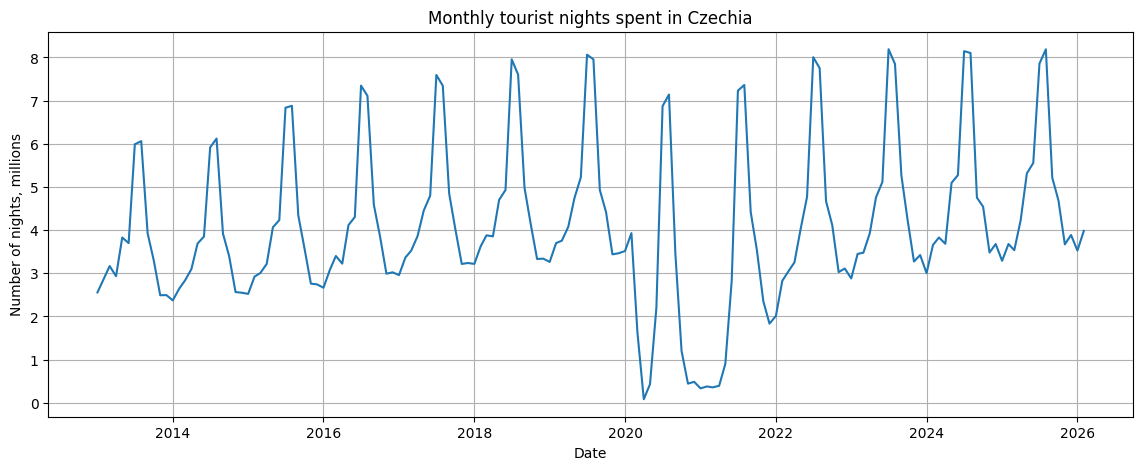

In [11]:
y = data_clean["nights_CZ_total"]

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000)

plt.title("Monthly tourist nights spent in Czechia")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.grid(True)
plt.show()

Видно очень резкий спад, связанный с пандемией. Для модели SARIMA это может быть проблемой, так как она предполагает, что данные являются стационарными. Поэтому перед применением модели необходимо провести тест на стационарность и, возможно, применить дифференцирование для достижения стационарности.

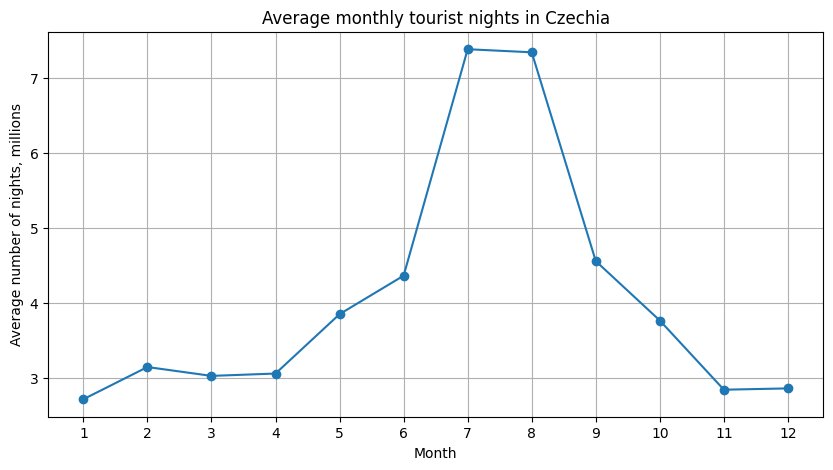

In [12]:
monthly_avg = y.groupby(y.index.month).mean() / 1_000_000

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Average monthly tourist nights in Czechia")
plt.xlabel("Month")
plt.ylabel("Average number of nights, millions")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

<Figure size 1200x500 with 0 Axes>

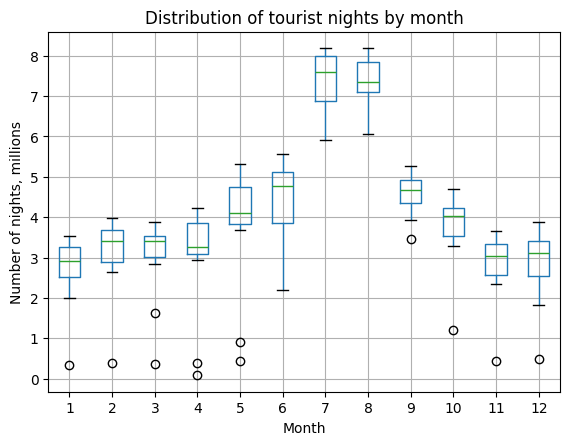

In [13]:
season_df = pd.DataFrame({
    "nights_millions": y / 1_000_000,
    "month": y.index.month
})

plt.figure(figsize=(12, 5))
season_df.boxplot(column="nights_millions", by="month")
plt.title("Distribution of tourist nights by month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Number of nights, millions")
plt.grid(True)
plt.show()

Hlavní časovou řadou je měsíční počet přenocování turistů v hromadných ubytovacích zařízeních v České republice. Data jsou k dispozici od ledna 2013 do března 2026. Řada má měsíční frekvenci a vykazuje zřetelnou sezónní složku. Nejvyšší hodnoty lze očekávat v letních měsících, zatímco nižší hodnoty se objevují převážně v zimním období.

Z grafického zobrazení je patrné, že řada obsahuje sezónnost, možný dlouhodobý trend a nepravidelné výkyvy. Výrazné narušení lze pozorovat v období kolem roku 2020, což pravděpodobně souvisí s obdobím pandemie COVID-19. Tuto skutečnost je nutné zohlednit při interpretaci modelů.

## II - Decomposition + smoothing trend

In [14]:
data_clean = data.copy()
data_clean = data_clean.interpolate(method="time").ffill().bfill()

y = data_clean["nights_CZ_total"]

print("Missing values in y:", y.isna().sum())
print("Start:", y.index.min())
print("End:", y.index.max())
print("Observations:", len(y))

Missing values in y: 0
Start: 2013-01-01 00:00:00
End: 2026-02-01 00:00:00
Observations: 158


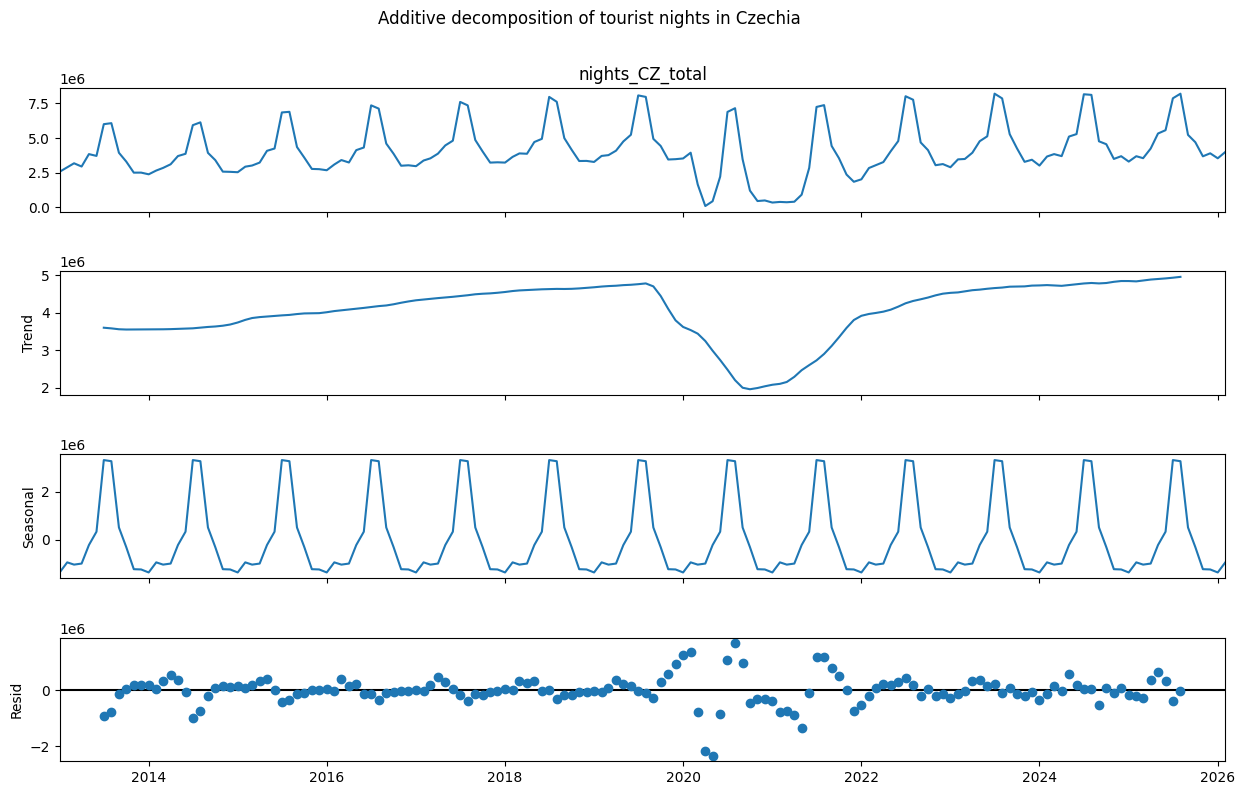

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_add = seasonal_decompose(
    y,
    model="additive",
    period=12
)

fig = decomp_add.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Additive decomposition of tourist nights in Czechia", y=1.02)
plt.show()

yt​=Tt​+St​+Rt​
Tt — trend;
St — seasonal component;
Rt — residual / irregular component

observed tourist nights = long-term trend + yearly seasonal effect + random irregular component

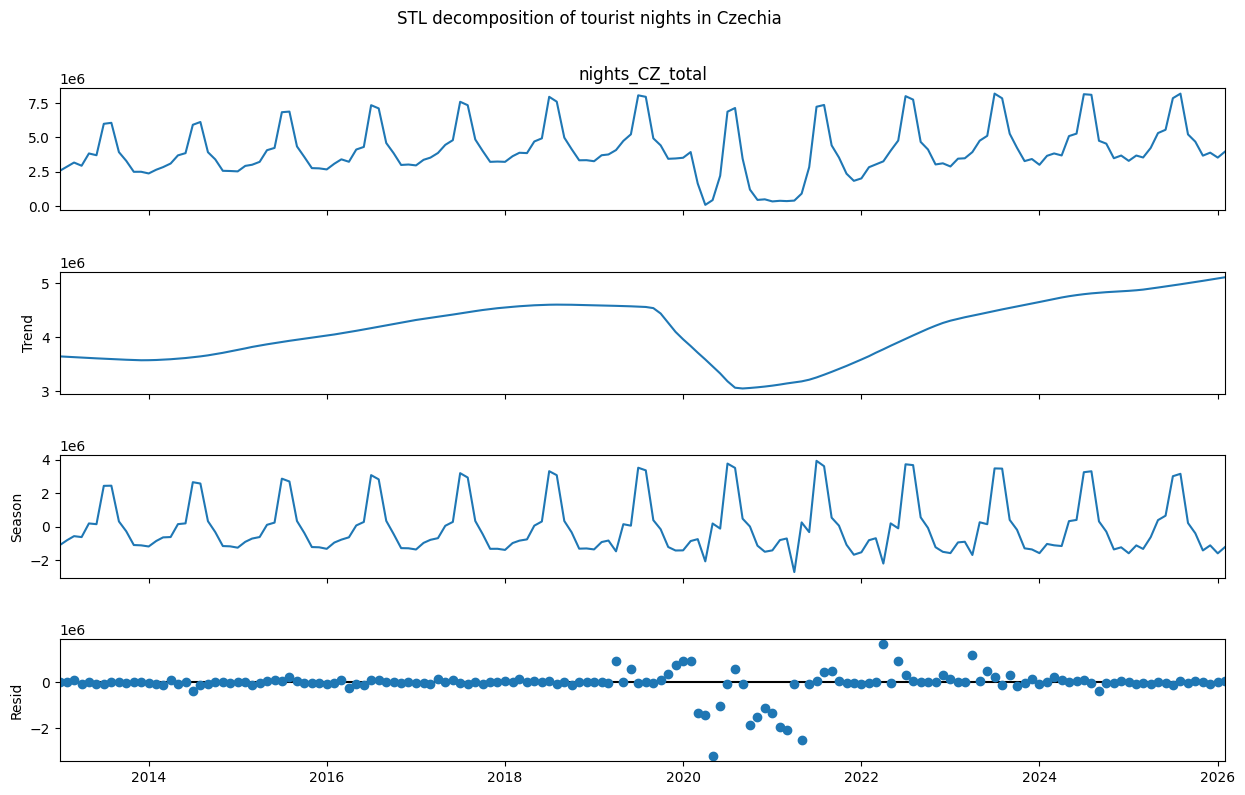

In [16]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    y,
    period=12,
    robust=True
)

stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 8)
plt.suptitle("STL decomposition of tourist nights in Czechia", y=1.02)
plt.show()

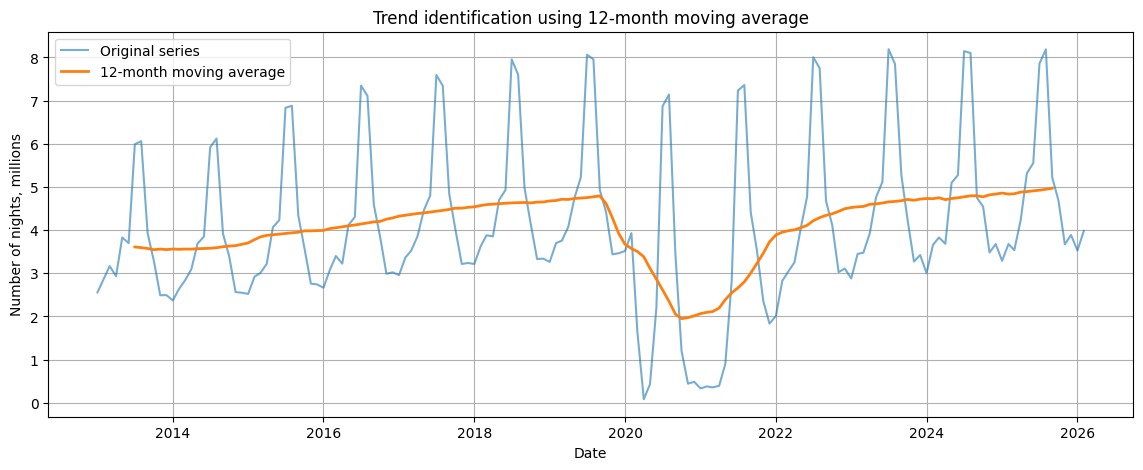

In [17]:
trend_ma_12 = y.rolling(window=12, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Original series", alpha=0.6)
plt.plot(trend_ma_12.index, trend_ma_12 / 1_000_000, label="12-month moving average", linewidth=2)

plt.title("Trend identification using 12-month moving average")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

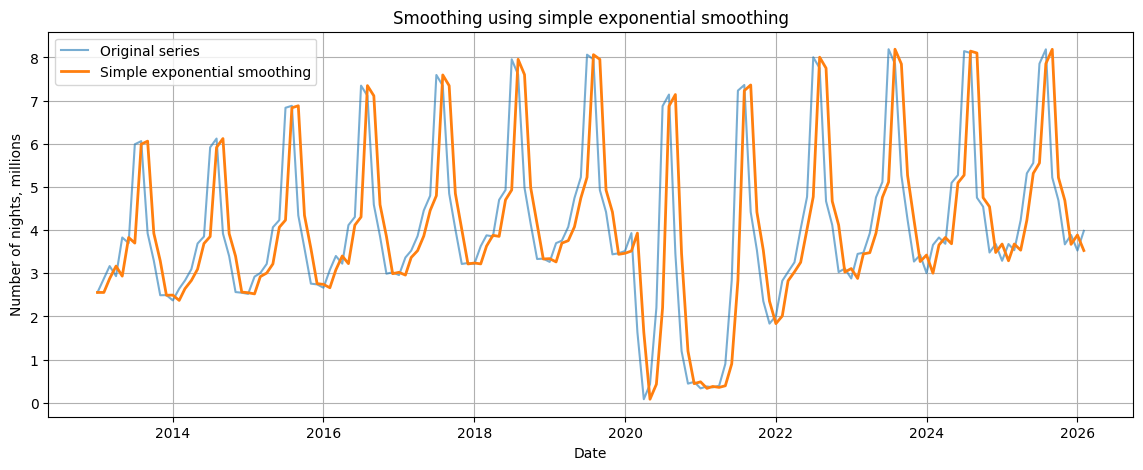

                        SimpleExpSmoothing Model Results                       
Dep. Variable:        nights_CZ_total   No. Observations:                   158
Model:             SimpleExpSmoothing   SSE                 281537469618153.250
Optimized:                       True   AIC                            4460.973
Trend:                           None   BIC                            4467.098
Seasonal:                        None   AICC                           4461.235
Seasonal Periods:                None   Date:                  Thu, 21 May 2026
Box-Cox:                        False   Time:                          10:32:17
Box-Cox Coeff.:                  None                                          
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
initial_level             2.5557e+06       

In [18]:
# Не включать в отчет, так как не отстраняет сезонность и почти полностью повторяет оригинальную серию
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(y).fit(optimized=True)
ses_fitted = ses_model.fittedvalues

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Original series", alpha=0.6)
plt.plot(ses_fitted.index, ses_fitted / 1_000_000, label="Simple exponential smoothing", linewidth=2)

plt.title("Smoothing using simple exponential smoothing")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

print(ses_model.summary())

Hlavní časová řada byla dekomponována na trendovou, sezónní a reziduální složku. Protože data mají měsíční frekvenci, sezónní perioda byla nastavena na hodnotu 12.

STL dekompozice potvrzuje výraznou roční sezónnost. Sezónní složka nabývá kladných hodnot zejména v letních měsících, především v červenci a srpnu, a záporných hodnot v zimním období. To odpovídá očekávanému sezónnímu chování cestovního ruchu.

Trendová složka ukazuje postupný růst od roku 2013 do roku 2019. V letech 2020 a 2021 dochází k výraznému poklesu trendu, což pravděpodobně souvisí s pandemií COVID-19 a omezeními cestovního ruchu. Po roce 2021 se trend postupně zotavuje a vrací se přibližně na předpandemickou úroveň, případně ji mírně překračuje.

Pro identifikaci dlouhodobého trendu byl použit také centrovaný 12měsíční klouzavý průměr. Toto vyhlazení odstraňuje většinu roční sezónnosti a potvrzuje stejný vývoj: růst před rokem 2020, výrazný pokles během pandemického období a následné postupné zotavení.

Reziduální složka obsahuje největší odchylky právě v období pandemie, což naznačuje, že toto období představuje mimořádný strukturální šok, který je vhodné zohlednit při konstrukci regresních modelů.

## III - Hledání optimálního modelu pro samotnou řadu funkční zápis trendu + sezónnost, včetně možnosti fourierových koeficientů

Model 1: linear trend + monthly seasonal dummies

Model 2: quadratic trend + monthly seasonal dummies

Model 3: quadratic trend + monthly seasonal dummies + COVID dummy

Model 4: trend + Fourier seasonality

Model 5: trend + Fourier seasonality + COVID dummy

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

model_df = pd.DataFrame({
    "y": y
})

model_df["t"] = np.arange(1, len(model_df) + 1)
model_df["t2"] = model_df["t"] ** 2
model_df["month"] = model_df.index.month.astype(str)

# COVID/intervention dummy based on the visible structural break
model_df["covid"] = (
    (model_df.index >= "2020-03-01") &
    (model_df.index <= "2021-12-01")
).astype(int)

display(model_df.head())
display(model_df.tail())

print(model_df.shape)

,y,t,t2,month,covid
date,,,,,
2013-01-01,2555690.0,1,1,1,0
2013-02-01,2876204.0,2,4,2,0
2013-03-01,3166229.0,3,9,3,0
2013-04-01,2933205.0,4,16,4,0
2013-05-01,3828516.0,5,25,5,0


,y,t,t2,month,covid
date,,,,,
2025-10-01,4686713.0,154,23716,10,0
2025-11-01,3669374.0,155,24025,11,0
2025-12-01,3886275.0,156,24336,12,0
2026-01-01,3526405.0,157,24649,1,0
2026-02-01,3982545.0,158,24964,2,0


(158, 5)


In [ ]:
# Model 1: Linear trend + month dummies yt​=β0​+β1​t+Sm​+εt​
model_1 = smf.ols(
    formula="y ~ t + C(month)",
    data=model_df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     38.60
Date:                Thu, 21 May 2026   Prob (F-statistic):           3.83e-39
Time:                        10:32:17   Log-Likelihood:                -2388.8
No. Observations:                 158   AIC:                             4804.
Df Residuals:                     145   BIC:                             4843.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.292e+06    2.8e+05      8.

In [21]:
# Model 2: Quadratic trend + month dummies yt​=β0​+β1​t+β2​*t**2+Sm​+εt​
model_2 = smf.ols(
    formula="y ~ t + I(t**2) + C(month)",
    data=model_df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     37.00
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.21e-39
Time:                        10:33:03   Log-Likelihood:                -2386.1
No. Observations:                 158   AIC:                             4800.
Df Residuals:                     144   BIC:                             4843.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.642e+06   3.17e+05      8.

In [22]:
# Model 3: quadratic trend + month dummies + COVID dummy yt​=β0​+β1​t+β2​*t**2+Sm​+γDcovid,t​+εt​
model_3 = smf.ols(
    formula="y ~ t + I(t**2) + C(month) + covid",
    data=model_df
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     114.5
Date:                Thu, 21 May 2026   Prob (F-statistic):           3.05e-70
Time:                        10:35:25   Log-Likelihood:                -2304.4
No. Observations:                 158   AIC:                             4639.
Df Residuals:                     143   BIC:                             4685.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1.984e+06   1.94e+05     10.

In [ ]:
# Model 4: trend + Fourier terms (the formula is too complex to write 0_0)
def add_fourier_terms(df, period=12, K=2):
    df = df.copy()
    t = df["t"].values

    for k in range(1, K + 1):
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return df

# several models with different number of Fourier terms

fourier_models = {}

for K in range(1, 6):
    df_k = add_fourier_terms(model_df, period=12, K=K)

    fourier_terms = " + ".join(
        [f"sin_{k} + cos_{k}" for k in range(1, K + 1)]
    )

    formula = f"y ~ t + I(t**2) + covid + {fourier_terms}"

    fit = smf.ols(
        formula=formula,
        data=df_k
    ).fit()

    fourier_models[f"Fourier_K{K}"] = {
        "fit": fit,
        "data": df_k,
        "formula": formula
    }

for name, obj in fourier_models.items():
    print(name, "AIC:", obj["fit"].aic, "BIC:", obj["fit"].bic)

Fourier_K1 AIC: 4825.535492588188 BIC: 4843.91106278635
Fourier_K2 AIC: 4727.133139051352 BIC: 4751.633899315568
Fourier_K3 AIC: 4683.337616178241 BIC: 4713.963566508511
Fourier_K4 AIC: 4660.70776698151 BIC: 4697.458907377833
Fourier_K5 AIC: 4636.8520551659685 BIC: 4679.728385628346


In [ ]:
models = {
    "M1_linear_trend_month_dummies": model_1,
    "M2_quadratic_trend_month_dummies": model_2,
    "M3_quadratic_trend_month_dummies_covid": model_3,
}

for name, obj in fourier_models.items():
    models[name] = obj["fit"]


comparison_rows = []

for name, fit in models.items():
    resid = fit.resid
    rmse = np.sqrt(np.mean(resid ** 2))

    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    lb_pvalue = lb["lb_pvalue"].iloc[0]

    comparison_rows.append({
        "model": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "Adj_R2": fit.rsquared_adj,
        "RMSE": rmse,
        "Ljung_Box_pvalue_lag12": lb_pvalue
    })

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.sort_values("AIC")

display(comparison)

,model,AIC,BIC,Adj_R2,RMSE,Ljung_Box_pvalue_lag12
7,Fourier_K5,4636.852055,4679.728386,0.910645,522320.323345,8.297314e-25
2,M3_quadratic_trend_month_dummies_covid,4638.804808,4684.743733,0.910047,522242.233374,7.764359e-25
6,Fourier_K4,4660.707767,4697.458907,0.894877,570453.713441,4.263039e-18
5,Fourier_K3,4683.337616,4713.963567,0.877260,620610.522580,6.348162e-14
4,Fourier_K2,4727.133139,4751.633899,0.836118,721949.622860,9.662100e-18
1,M2_quadratic_trend_month_dummies,4800.168753,4843.045084,0.748795,875772.224901,3.590983e-102
0,M1_linear_trend_month_dummies,4803.562971,4843.376707,0.741863,890850.255096,4.655513e-107
3,Fourier_K1,4825.535493,4843.911063,0.690791,998259.679973,5.718331e-50


Best model by AIC: Fourier_K5


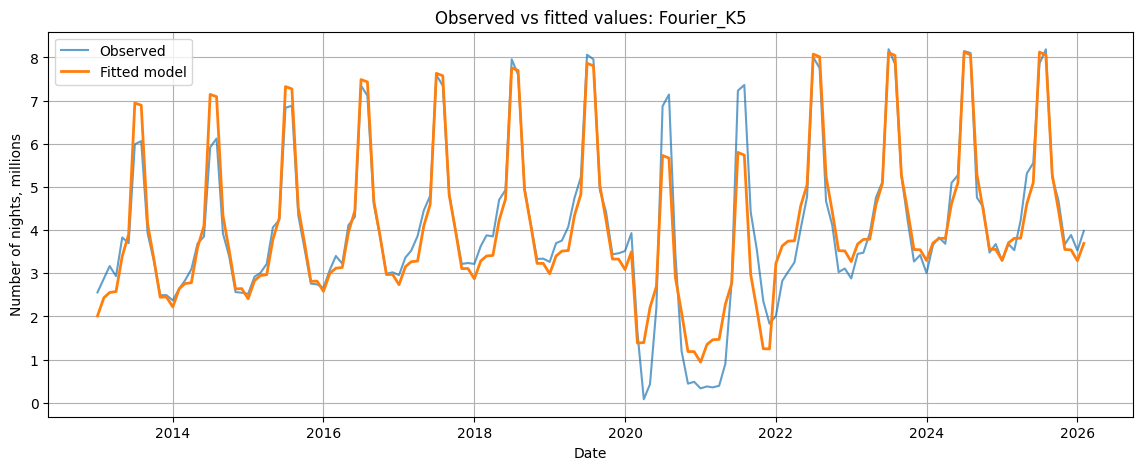

In [26]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name]

print("Best model by AIC:", best_name)

plt.figure(figsize=(14, 5))
plt.plot(model_df.index, model_df["y"] / 1_000_000, label="Observed", alpha=0.7)
plt.plot(model_df.index, best_model.fittedvalues / 1_000_000, label="Fitted model", linewidth=2)

plt.title(f"Observed vs fitted values: {best_name}")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

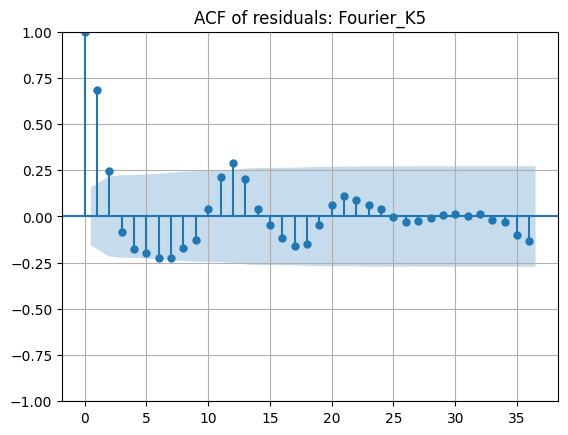

In [27]:
plt.figure(figsize=(10, 4))
plot_acf(best_model.resid, lags=36)
plt.title(f"ACF of residuals: {best_name}")
plt.grid(True)
plt.show()

In [28]:
print(model_3.params["covid"])
print(model_3.pvalues["covid"])

-2225466.2602687967
6.472245934935168e-34


In [29]:
best_fourier_fit = fourier_models["Fourier_K5"]["fit"]

print("COVID coefficient in Fourier_K5:")
print(best_fourier_fit.params["covid"])

print("COVID p-value in Fourier_K5:")
print(best_fourier_fit.pvalues["covid"])

COVID coefficient in Fourier_K5:
-2225520.9363846155
COVID p-value in Fourier_K5:
3.8906227007731435e-34


#### Regresní model s trendem a sezónností

Pro popis hlavní časové řady bylo odhadnuto několik regresních modelů s deterministickým trendem a sezónní složkou. Testované modely zahrnovaly lineární trend se sezónními dummy proměnnými, kvadratický trend se sezónními dummy proměnnými, modely s COVID dummy proměnnou a harmonické regresní modely využívající Fourierovy členy.

Nejlepší model podle kritéria AIC byl Fourierův model s \(K=5\) harmonickými složkami. Model má tvar:

\[
y_t =
\beta_0 +
\beta_1 t +
\beta_2 t^2 +
\gamma D_{covid,t}
+
\sum_{k=1}^{5}
\left[
a_k \sin\left(\frac{2\pi kt}{12}\right)
+
b_k \cos\left(\frac{2\pi kt}{12}\right)
\right]
+
\varepsilon_t.
\]

Model dosáhl adjustovaného \(R^2\) přibližně 0.91, což znamená, že vysvětluje většinu variability časové řady. Vyrovnané hodnoty poměrně dobře kopírují pozorovanou řadu včetně pravidelných sezónních maxim.

Diagnostika reziduí však ukazuje, že rezidua nejsou nezávislá. Ljungův-Boxův test dává velmi malou p-hodnotu a ACF reziduí obsahuje významnou autokorelaci, zejména na prvním zpoždění. Model tedy dobře popisuje trend a sezónnost, ale nezachycuje plně závislostní strukturu časové řady. To je důvodem pro použití SARIMA modelů v dalším kroku.

## IV - Hledání optimálního SARIMA modelu pro samotnou řadu

<Figure size 1000x400 with 0 Axes>

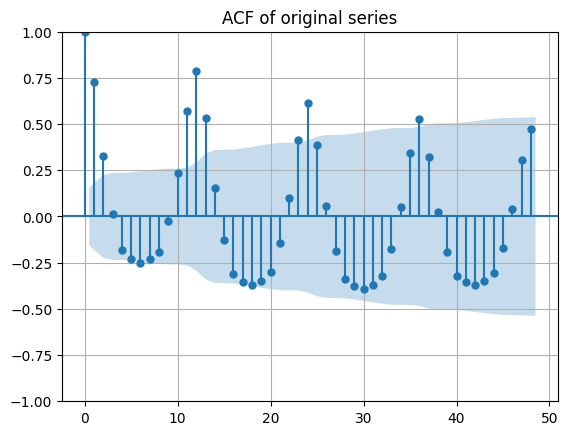

<Figure size 1000x400 with 0 Axes>

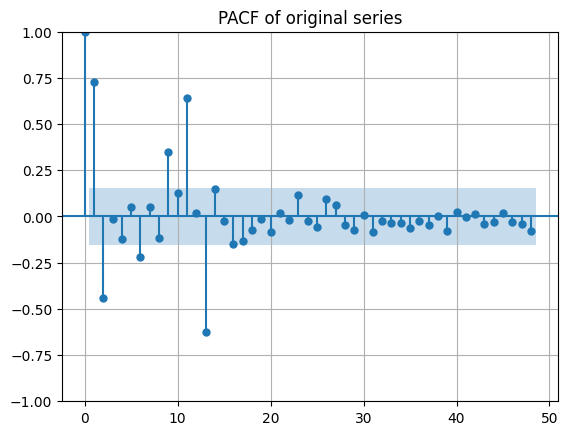

In [ ]:
# ACF and PACF of original series to check for remaining autocorrelation after fitting the model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10, 4))
plot_acf(y, lags=48)
plt.title("ACF of original series")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(y, lags=48, method="ywm")
plt.title("PACF of original series")
plt.grid(True)
plt.show()

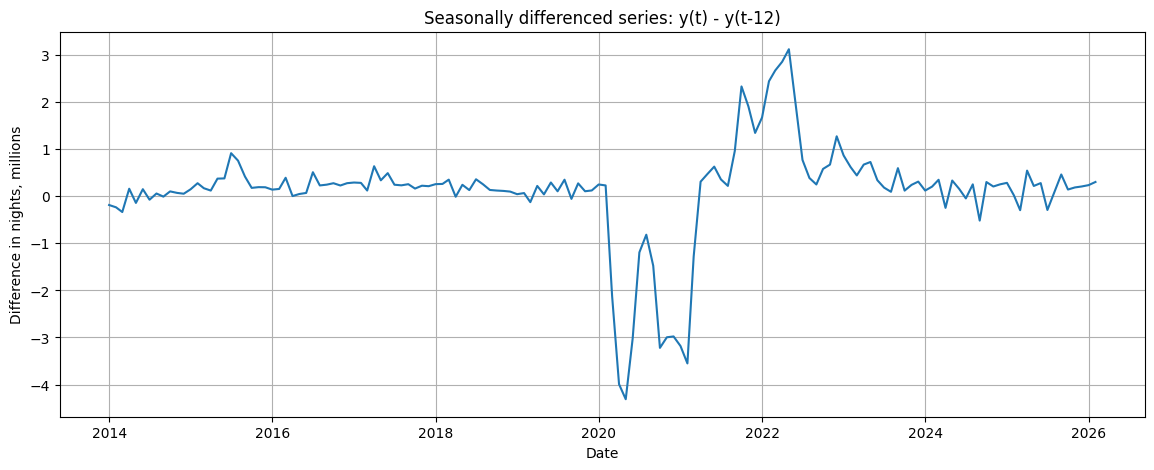

<Figure size 1000x400 with 0 Axes>

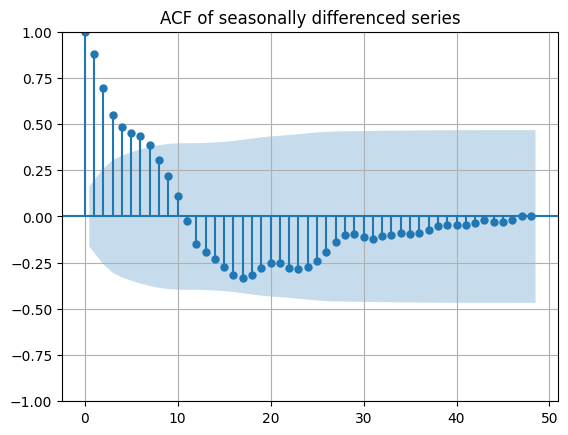

<Figure size 1000x400 with 0 Axes>

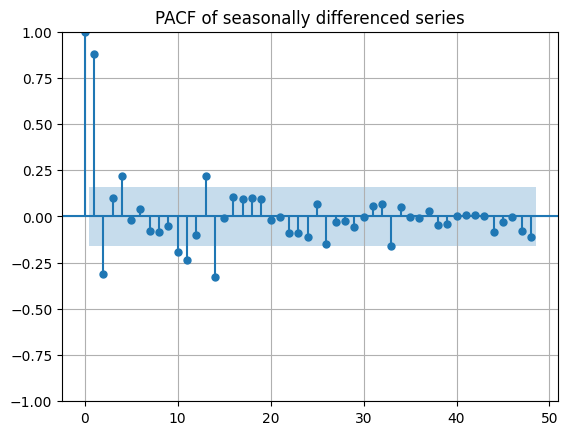

In [31]:
# Seasonal differencing to remove seasonality and check if it helps with autocorrelation
y_seasonal_diff = y.diff(12).dropna()

plt.figure(figsize=(14, 5))
plt.plot(y_seasonal_diff.index, y_seasonal_diff / 1_000_000)
plt.title("Seasonally differenced series: y(t) - y(t-12)")
plt.xlabel("Date")
plt.ylabel("Difference in nights, millions")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(y_seasonal_diff, lags=48)
plt.title("ACF of seasonally differenced series")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(y_seasonal_diff, lags=48, method="ywm")
plt.title("PACF of seasonally differenced series")
plt.grid(True)
plt.show()

In [32]:
# Auto sarima to find optimal SARIMA model for the series itself, without regressors
import pmdarima as pm

sarima_auto = pm.auto_arima(
    y,
    seasonal=True,
    m=12,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    information_criterion="aic"
)

print(sarima_auto.summary())
print("Selected order:", sarima_auto.order)
print("Selected seasonal order:", sarima_auto.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=5008.100, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=4804.571, Time=0.13 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=4867.094, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=5288.319, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=4889.710, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=4806.547, Time=0.20 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=4798.061, Time=0.31 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=4814.653, Time=0.06 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.19 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=4795.046, Time=0.46 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=4797.859, Time=0.14 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=1.20 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=4929.329, Time=0.37 sec
 ARIMA(2,0,0)(1,0,2)[12] intercept   : AIC=4771.729, Time=0.56 sec
 ARIMA(2,0,0)(0,0,2)[12] inte

In [ ]:
# Fitting the selected SARIMA model to the data
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = sarima_auto.order
seasonal_order = sarima_auto.seasonal_order

sarima_model = SARIMAX(
    y,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                         nights_CZ_total   No. Observations:                  158
Model:             SARIMAX(2, 0, 0)x(0, 0, [1, 2], 12)   Log Likelihood               -2014.123
Date:                                 Thu, 21 May 2026   AIC                           4038.246
Time:                                         11:43:50   BIC                           4052.698
Sample:                                     01-01-2013   HQIC                          4044.119
                                          - 02-01-2026                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1862      0.290      4.095      0.000       0.618       1

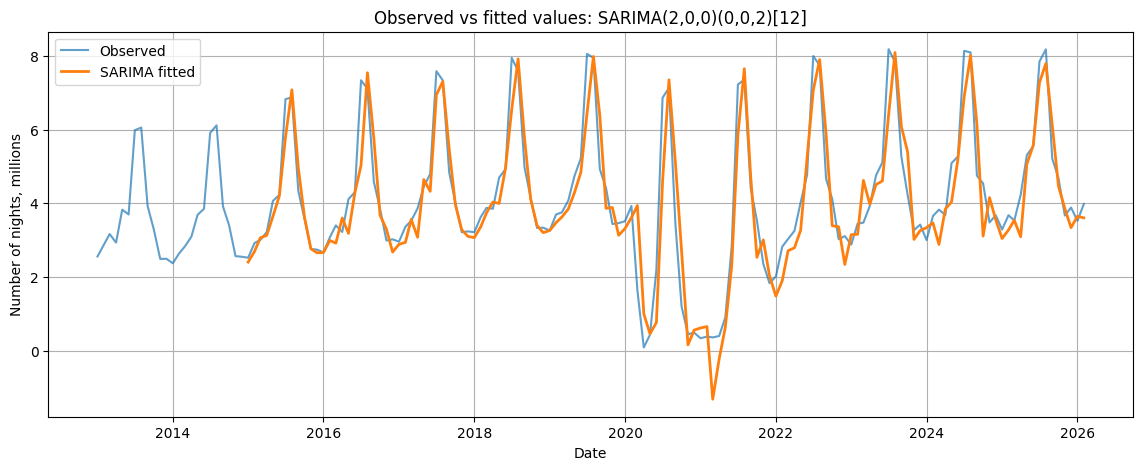

In [41]:
# we just want to show the fit from around 2015, because the beginning of the series is not well fitted and would distort the plot

burn = 24

sarima_fitted_trimmed = sarima_fit.fittedvalues.copy()
sarima_fitted_trimmed.iloc[:burn] = np.nan

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Observed", alpha=0.7)
plt.plot(
    sarima_fitted_trimmed.index,
    sarima_fitted_trimmed / 1_000_000,
    label="SARIMA fitted",
    linewidth=2
)

plt.title("Observed vs fitted values: SARIMA(2,0,0)(0,0,2)[12]")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

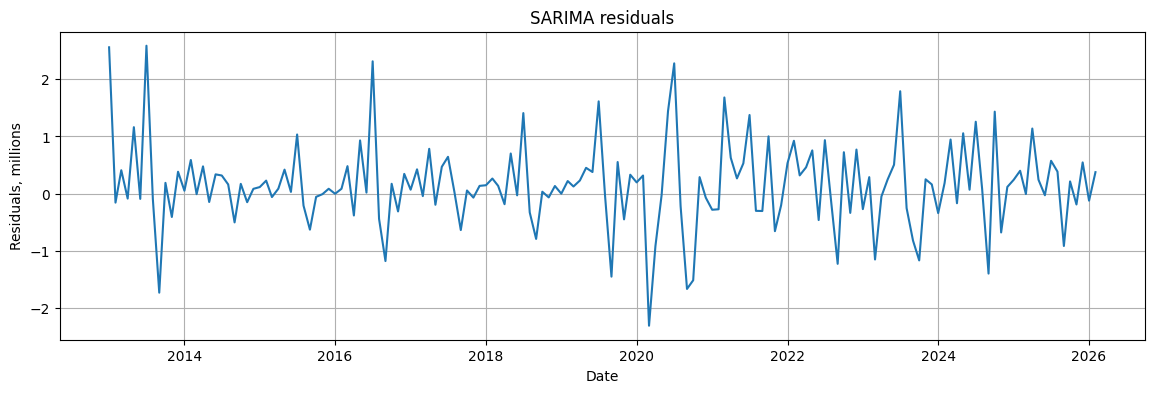

<Figure size 1000x400 with 0 Axes>

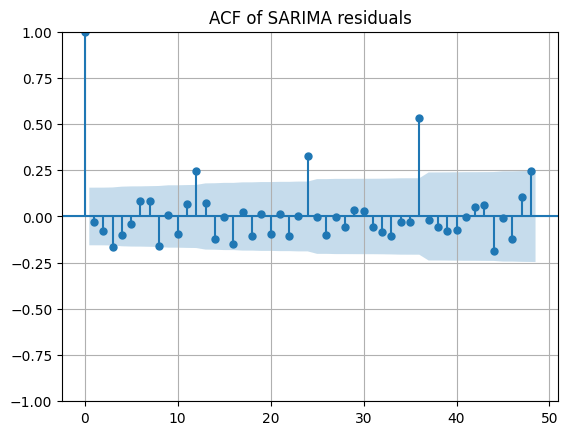

,lb_stat,lb_pvalue
12,26.958296,7.834721e-03
24,60.520264,5.391847e-05
36,127.661463,3.502889e-12


In [ ]:
sarima_resid = sarima_fit.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(sarima_resid.index, sarima_resid / 1_000_000)
plt.title("SARIMA residuals")
plt.xlabel("Date")
plt.ylabel("Residuals, millions")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(sarima_resid, lags=48)
plt.title("ACF of SARIMA residuals")
plt.grid(True)
plt.show()

lb_sarima = acorr_ljungbox(sarima_resid, lags=[12, 24, 36], return_df=True)
display(lb_sarima)

<Figure size 1000x400 with 0 Axes>

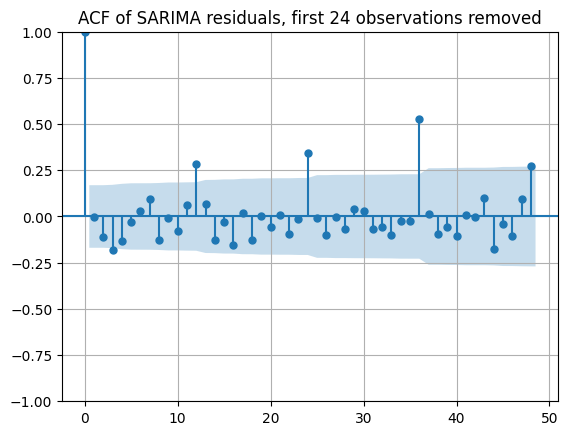

,lb_stat,lb_pvalue
12,26.275754,9.809478e-03
24,57.365634,1.489432e-04
36,115.797083,2.606770e-10


In [42]:
sarima_resid_trimmed = sarima_fit.resid.iloc[24:].dropna()

plt.figure(figsize=(10, 4))
plot_acf(sarima_resid_trimmed, lags=48)
plt.title("ACF of SARIMA residuals, first 24 observations removed")
plt.grid(True)
plt.show()

lb_sarima_trimmed = acorr_ljungbox(
    sarima_resid_trimmed,
    lags=[12, 24, 36],
    return_df=True
)

display(lb_sarima_trimmed)

#### SARIMA model

V dalším kroku byl pro hlavní časovou řadu odhadnut SARIMA model. Protože data mají měsíční frekvenci, sezónní perioda byla nastavena na hodnotu 12.

Automatický výběr modelu zvolil model

\[
SARIMA(2,0,0)(0,0,2)_{12}.
\]

Tento model obsahuje nesezónní autoregresní část řádu 2 a sezónní klouzavý průměr na zpožděních 12 a 24 měsíců. Nebylo zvoleno běžné ani sezónní diferencování.

Vyrovnané hodnoty poměrně dobře sledují pozorovanou časovou řadu a zachycují opakující se sezónní maxima. Diagnostika reziduí však ukazuje, že model zcela neodstranil autokorelaci. Ljungův-Boxův test dává p-hodnoty menší než 0.05 pro zpoždění 12, 24 a 36 a ACF reziduí stále obsahuje významné sezónní hodnoty.

SARIMA model tedy lépe zachycuje závislostní strukturu než jednoduchý regresní model, ale stále není zcela uspokojivý. Jedním z možných důvodů je výrazný strukturální zlom v období pandemie COVID-19, který čistý SARIMA model nedokáže plně vysvětlit.

## V - Hledání závislostí na jiných řadách pomocí kroskorelační funkce + nalezení zpoždění závislosti

In [43]:
def deterministic_residuals(series):
    df = pd.DataFrame({
        "value": series
    }).dropna()

    df["t"] = np.arange(1, len(df) + 1)
    df["month"] = df.index.month.astype(str)
    df["covid"] = (
        (df.index >= "2020-03-01") &
        (df.index <= "2021-12-01")
    ).astype(int)

    fit = smf.ols(
        "value ~ t + I(t**2) + C(month) + covid",
        data=df
    ).fit()

    return fit.resid


def lagged_cross_correlation(y_resid, x_resid, max_lag=24):
    """
    Positive lag means:
    x leads y by this number of months.

    Example:
    lag = 2 means x(t-2) is correlated with y(t).
    """
    result = []

    common = pd.concat([y_resid, x_resid], axis=1).dropna()
    yv = common.iloc[:, 0]
    xv = common.iloc[:, 1]

    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            y_aligned = yv.iloc[lag:]
            x_aligned = xv.iloc[:-lag]
        elif lag < 0:
            y_aligned = yv.iloc[:lag]
            x_aligned = xv.iloc[-lag:]
        else:
            y_aligned = yv
            x_aligned = xv

        corr = np.corrcoef(y_aligned, x_aligned)[0, 1]

        result.append({
            "lag": lag,
            "correlation": corr,
            "abs_correlation": abs(corr)
        })

    return pd.DataFrame(result)

In [44]:
external_candidates = [
    "arrivals_CZ_total",
    "arrivals_AT_total",
    "arrivals_DE_total",
    "arrivals_SK_total",
    "arrivals_PL_total",
    "nights_AT_total",
    "nights_DE_total",
    "nights_SK_total",
    "nights_PL_total",
]

In [45]:
y_resid = deterministic_residuals(data_clean["nights_CZ_total"])

ccf_summary = []

for col in external_candidates:
    x_resid = deterministic_residuals(data_clean[col])

    ccf_df = lagged_cross_correlation(
        y_resid,
        x_resid,
        max_lag=24
    )

    best_row = ccf_df.loc[ccf_df["abs_correlation"].idxmax()]

    ccf_summary.append({
        "series": col,
        "best_lag": int(best_row["lag"]),
        "correlation": best_row["correlation"],
        "abs_correlation": best_row["abs_correlation"]
    })

ccf_summary = pd.DataFrame(ccf_summary)
ccf_summary = ccf_summary.sort_values("abs_correlation", ascending=False)

display(ccf_summary)

,series,best_lag,correlation,abs_correlation
0,arrivals_CZ_total,0,0.988636,0.988636
2,arrivals_DE_total,0,0.900140,0.900140
4,arrivals_PL_total,0,0.891291,0.891291
6,nights_DE_total,0,0.878173,0.878173
3,arrivals_SK_total,0,0.873324,0.873324
8,nights_PL_total,0,0.869852,0.869852
7,nights_SK_total,0,0.857173,0.857173
1,arrivals_AT_total,0,0.849633,0.849633
5,nights_AT_total,0,0.734615,0.734615


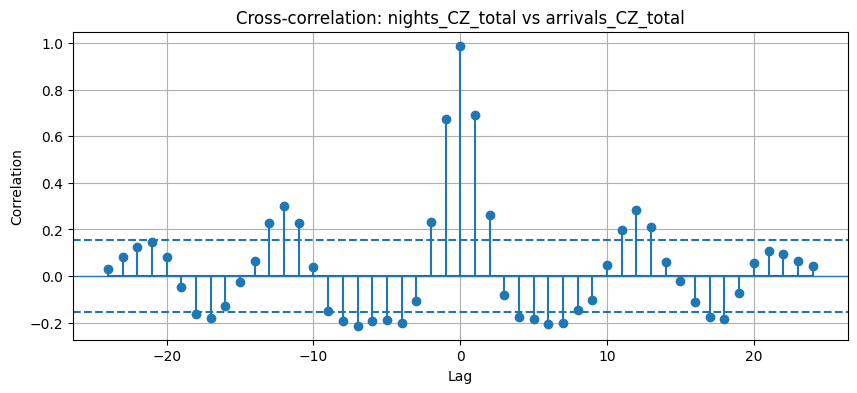

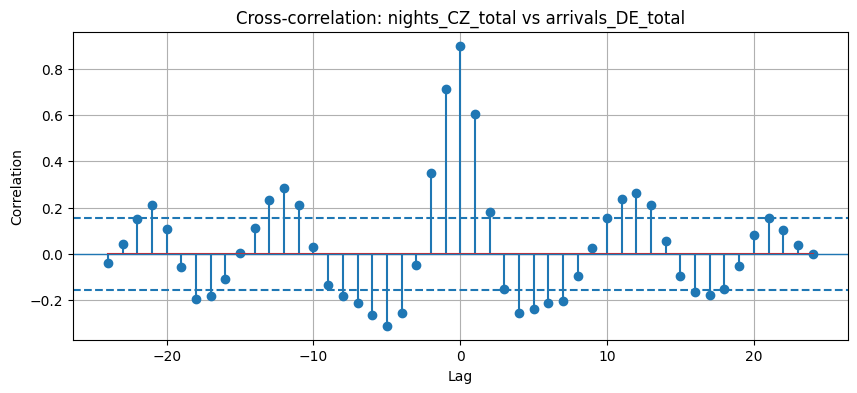

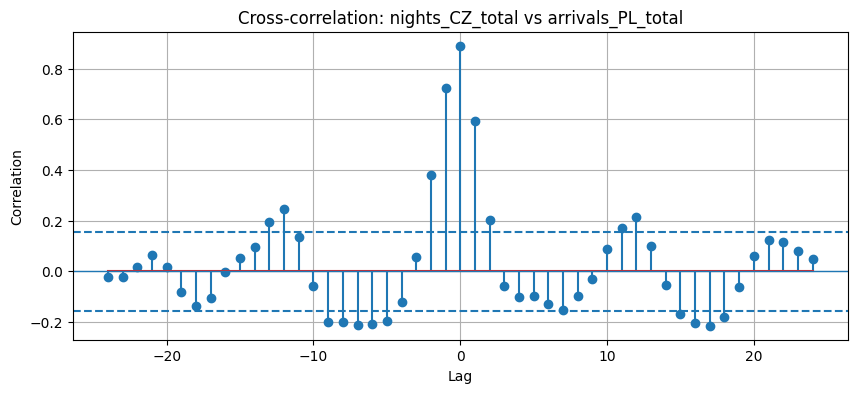

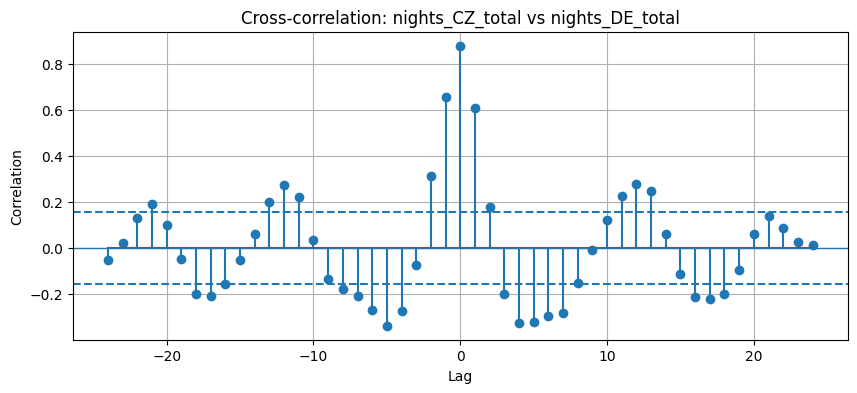

In [46]:
top_series = ccf_summary.head(4)["series"].tolist()

for col in top_series:
    x_resid = deterministic_residuals(data_clean[col])

    ccf_df = lagged_cross_correlation(
        y_resid,
        x_resid,
        max_lag=24
    )

    plt.figure(figsize=(10, 4))
    plt.stem(ccf_df["lag"], ccf_df["correlation"])
    plt.axhline(0, linewidth=1)

    # approximate significance band
    n = len(y_resid.dropna())
    bound = 1.96 / np.sqrt(n)
    plt.axhline(bound, linestyle="--")
    plt.axhline(-bound, linestyle="--")

    plt.title(f"Cross-correlation: nights_CZ_total vs {col}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.show()

#### Kroskorelace s ostatními časovými řadami

Pro identifikaci možných závislostí mezi hlavní časovou řadou a ostatními řadami z oblasti cestovního ruchu byla použita kroskorelační funkce. Protože všechny turistické řady obsahují výrazný trend a sezónnost, kroskorelace nebyla počítána přímo ze surových dat. Nejprve byly odstraněny deterministické složky pomocí regresního modelu s kvadratickým trendem, měsíčními sezónními dummy proměnnými a COVID dummy proměnnou. Kroskorelace byla následně počítána z reziduí.

Nejsilnější vztah byl nalezen mezi počtem přenocování v České republice a počtem příjezdů turistů do České republiky. Maximální korelace byla pozorována při zpoždění 0 a dosáhla přibližně hodnoty 0.989. To znamená, že vztah je převážně současný: měsíce s vysokým počtem příjezdů mají zároveň vysoký počet přenocování.

Silné kladné korelace byly nalezeny také s turistickými řadami sousedních zemí, zejména Německa, Polska a Slovenska. U všech vybraných řad byla nejsilnější korelace pozorována při zpoždění 0. Nebyla tedy identifikována výrazná zpožděná závislost. Výsledky naznačují, že česká turistická řada souvisí s ostatními turistickými ukazateli převážně ve stejném měsíci.

## VI - Hledání optimálního modelu kombinujícího závislost na ostatních řadách a řešení autokorelace

Construct model with different combinations of regressors and check if it helps with autocorrelation in residuals

Model A: arrivals_CZ_total
Model B: arrivals_CZ_total + arrivals_DE_total
Model C: arrivals_CZ_total + arrivals_DE_total + arrivals_PL_total
Model D: arrivals_DE_total + arrivals_PL_total + arrivals_SK_total

In [47]:
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarimax_with_exog(y, exog_cols, order=(2, 0, 0), seasonal_order=(0, 0, 2, 12)):
    """
    Fits SARIMAX model with selected external regressors.
    External variables are standardized for numerical stability.
    """
    df = pd.concat([y, data_clean[exog_cols]], axis=1).dropna()
    y_model = df.iloc[:, 0]
    X = df[exog_cols]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        index=X.index,
        columns=exog_cols
    )

    model = SARIMAX(
        y_model,
        exog=X_scaled,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    return {
        "fit": fit,
        "y": y_model,
        "X_scaled": X_scaled,
        "scaler": scaler,
        "exog_cols": exog_cols
    }

In [48]:
exog_model_specs = {
    "A_CZ_arrivals": [
        "arrivals_CZ_total"
    ],
    "B_CZ_DE_arrivals": [
        "arrivals_CZ_total",
        "arrivals_DE_total"
    ],
    "C_CZ_DE_PL_arrivals": [
        "arrivals_CZ_total",
        "arrivals_DE_total",
        "arrivals_PL_total"
    ],
    "D_external_arrivals_only": [
        "arrivals_DE_total",
        "arrivals_PL_total",
        "arrivals_SK_total"
    ],
    "E_external_nights_only": [
        "nights_DE_total",
        "nights_PL_total",
        "nights_SK_total"
    ]
}

sarimax_exog_results = {}

for name, cols in exog_model_specs.items():
    print("Fitting:", name, cols)
    result = fit_sarimax_with_exog(
        y=y,
        exog_cols=cols,
        order=(2, 0, 0),
        seasonal_order=(0, 0, 2, 12)
    )
    sarimax_exog_results[name] = result

print("Done.")

Fitting: A_CZ_arrivals ['arrivals_CZ_total']
Fitting: B_CZ_DE_arrivals ['arrivals_CZ_total', 'arrivals_DE_total']
Fitting: C_CZ_DE_PL_arrivals ['arrivals_CZ_total', 'arrivals_DE_total', 'arrivals_PL_total']
Fitting: D_external_arrivals_only ['arrivals_DE_total', 'arrivals_PL_total', 'arrivals_SK_total']
Fitting: E_external_nights_only ['nights_DE_total', 'nights_PL_total', 'nights_SK_total']
Done.


In [49]:
sarimax_comparison_rows = []

for name, obj in sarimax_exog_results.items():
    fit = obj["fit"]
    resid = fit.resid.dropna()

    rmse = np.sqrt(np.mean(resid ** 2))

    lb = acorr_ljungbox(
        resid.iloc[24:],
        lags=[12],
        return_df=True
    )

    sarimax_comparison_rows.append({
        "model": name,
        "exog": ", ".join(obj["exog_cols"]),
        "AIC": fit.aic,
        "BIC": fit.bic,
        "RMSE": rmse,
        "Ljung_Box_pvalue_lag12": lb["lb_pvalue"].iloc[0]
    })

sarimax_comparison = pd.DataFrame(sarimax_comparison_rows)
sarimax_comparison = sarimax_comparison.sort_values("AIC")

display(sarimax_comparison)

,model,exog,AIC,BIC,RMSE,Ljung_Box_pvalue_lag12
4,E_external_nights_only,"nights_DE_total, nights_PL_total, nights_SK_total",3663.138104,3689.151247,405273.898513,6.490804e-02
1,B_CZ_DE_arrivals,"arrivals_CZ_total, arrivals_DE_total",3667.628507,3690.751300,401540.547413,1.635127e-02
2,C_CZ_DE_PL_arrivals,"arrivals_CZ_total, arrivals_DE_total, arrivals...",3675.608882,3701.622024,405611.820467,2.375114e-01
0,A_CZ_arrivals,arrivals_CZ_total,3703.229843,3723.462287,425480.148726,4.717679e-11
3,D_external_arrivals_only,"arrivals_DE_total, arrivals_PL_total, arrivals...",3850.483454,3876.496596,527957.971401,1.890964e-05


In [50]:
best_sarimax_name = sarimax_comparison.iloc[0]["model"]
best_sarimax = sarimax_exog_results[best_sarimax_name]["fit"]

print("Best SARIMAX model by AIC:", best_sarimax_name)
print(best_sarimax.summary())

Best SARIMAX model by AIC: E_external_nights_only
                                        SARIMAX Results                                        
Dep. Variable:                         nights_CZ_total   No. Observations:                  158
Model:             SARIMAX(2, 0, 0)x(0, 0, [1, 2], 12)   Log Likelihood               -1822.569
Date:                                 Thu, 21 May 2026   AIC                           3663.138
Time:                                         12:28:18   BIC                           3689.151
Sample:                                     01-01-2013   HQIC                          3673.709
                                          - 02-01-2026                                         
Covariance Type:                                   opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept     

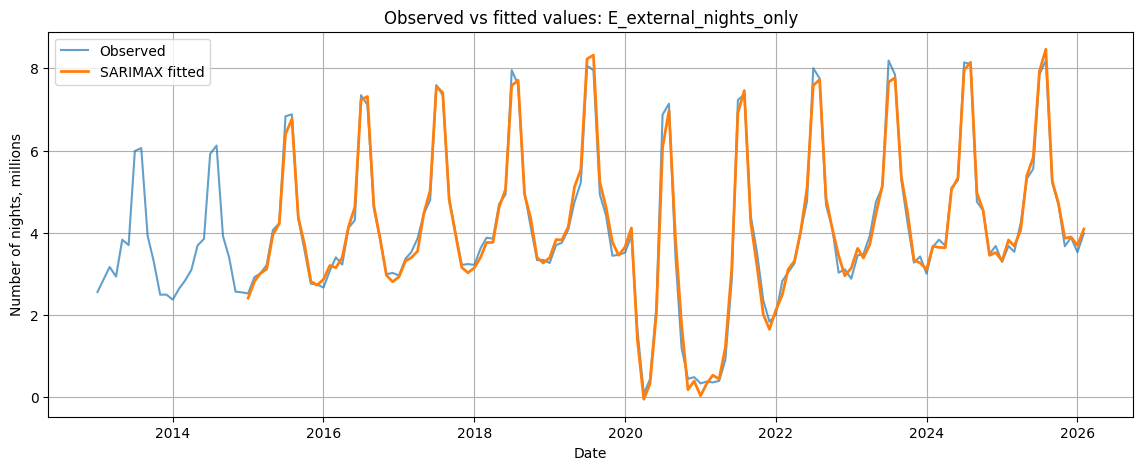

In [51]:
best_obj = sarimax_exog_results[best_sarimax_name]
best_fit = best_obj["fit"]
best_y = best_obj["y"]

fitted = best_fit.fittedvalues.copy()
fitted.iloc[:24] = np.nan

plt.figure(figsize=(14, 5))
plt.plot(best_y.index, best_y / 1_000_000, label="Observed", alpha=0.7)
plt.plot(fitted.index, fitted / 1_000_000, label="SARIMAX fitted", linewidth=2)

plt.title(f"Observed vs fitted values: {best_sarimax_name}")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

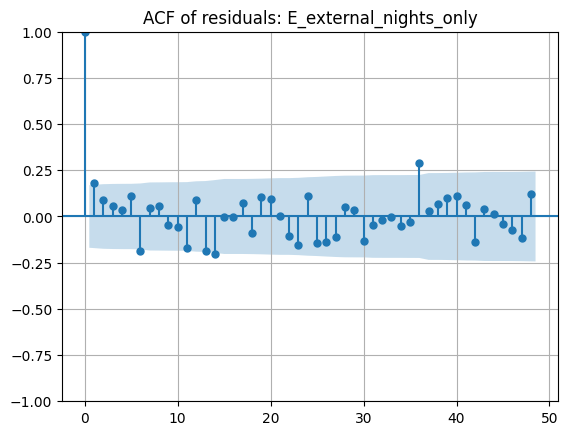

,lb_stat,lb_pvalue
12,20.116825,0.064908
24,44.896423,0.005991
36,73.972873,0.000197


In [52]:
best_resid = best_fit.resid.iloc[24:].dropna()

plt.figure(figsize=(10, 4))
plot_acf(best_resid, lags=48)
plt.title(f"ACF of residuals: {best_sarimax_name}")
plt.grid(True)
plt.show()

lb_best_sarimax = acorr_ljungbox(
    best_resid,
    lags=[12, 24, 36],
    return_df=True
)

display(lb_best_sarimax)

#### Regresní model s externími proměnnými a autokorelovanými chybami

V tomto kroku byly odhadnuty modely kombinující externí časové řady z oblasti cestovního ruchu s autoregresní strukturou chyb. Cílem bylo vysvětlit hlavní českou turistickou řadu nejen pomocí její vlastní minulosti, ale také pomocí souvisejících časových řad z jiných zemí.

Bylo porovnáno několik SARIMAX modelů. Externími regresory byly počty příjezdů turistů a počty přenocování v sousedních zemích. Nejlepší model podle kritéria AIC využívá jako externí proměnné celkový počet přenocování v Německu, Polsku a na Slovensku.

Vybraný model lze zapsat ve tvaru:

\[
y_t =
\beta_0
+ \beta_1 x_{DE,t}
+ \beta_2 x_{PL,t}
+ \beta_3 x_{SK,t}
+ n_t,
\]

kde \(n_t\) má strukturu

\[
SARIMA(2,0,0)(0,0,2)_{12}.
\]

Model dosáhl hodnoty AIC = 3663.14 a RMSE přibližně 405 tisíc přenocování. To představuje výrazné zlepšení oproti čistému SARIMA modelu. Vyrovnané hodnoty velmi dobře sledují pozorovanou časovou řadu, včetně sezónních maxim a období pandemie COVID-19.

Všechny tři externí proměnné mají kladné koeficienty a jsou statisticky významné. To znamená, že vyšší turistická aktivita v Německu, Polsku a na Slovensku je spojena s vyšší turistickou aktivitou v České republice.

Diagnostika reziduí se také zlepšila. Ljungův-Boxův test pro zpoždění 12 má p-hodnotu přibližně 0.065, takže na 5% hladině významnosti nezamítáme hypotézu o nulové autokorelaci pro toto zpoždění. Pro zpoždění 24 a 36 však významná autokorelace stále zůstává. Model je tedy lepší než čistý SARIMA model, ale rezidua stále nejsou dokonale nezávislá.

## VII - Kontrola periody pomocí periodogramu

In [54]:
from scipy.signal import periodogram

# Convert to numeric array and remove mean
y_values = y.values.astype(float)
y_centered = y_values - np.mean(y_values)

# fs = 1 means one observation per month
freqs, power = periodogram(y_centered, fs=1)

# Remove zero frequency
freqs_nonzero = freqs[1:]
power_nonzero = power[1:]

# Convert frequency to period in months
periods = 1 / freqs_nonzero

periodogram_df = pd.DataFrame({
    "frequency": freqs_nonzero,
    "period_months": periods,
    "power": power_nonzero
})

periodogram_df = periodogram_df.sort_values("power", ascending=False)

display(periodogram_df.head(10))

,frequency,period_months,power
12,0.082278,12.153846,2.529367e+14
1,0.012658,79.000000,6.013165e+13
25,0.164557,6.076923,5.870542e+13
26,0.170886,5.851852,2.484372e+13
13,0.088608,11.285714,1.570110e+13
3,0.025316,39.500000,1.443975e+13
14,0.094937,10.533333,9.868261e+12
39,0.253165,3.950000,8.948182e+12
2,0.018987,52.666667,8.744861e+12
38,0.246835,4.051282,8.293845e+12


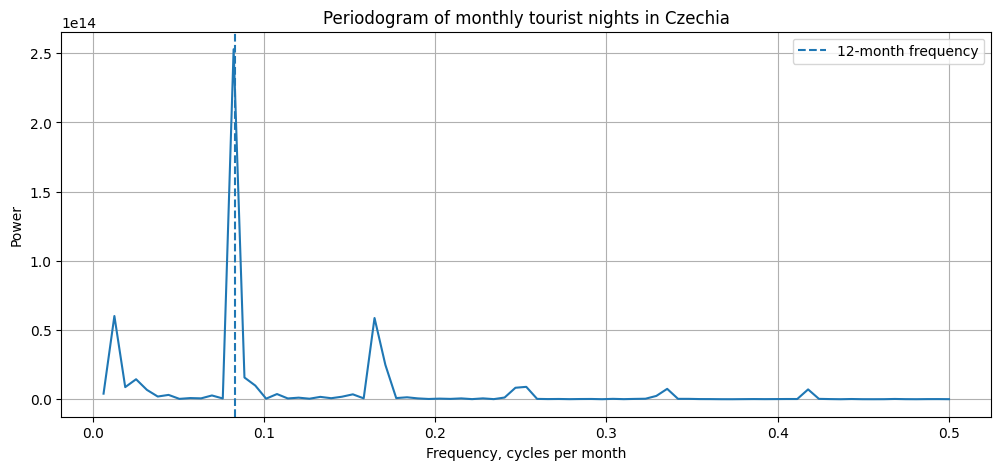

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(freqs_nonzero, power_nonzero)

plt.axvline(1/12, linestyle="--", label="12-month frequency")

plt.title("Periodogram of monthly tourist nights in Czechia")
plt.xlabel("Frequency, cycles per month")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

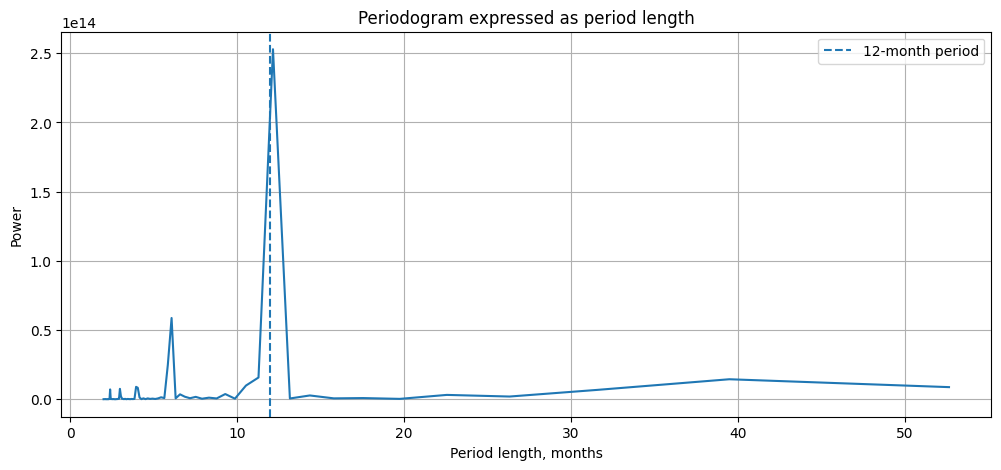

In [57]:
periodogram_plot_df = periodogram_df[
    (periodogram_df["period_months"] >= 2) &
    (periodogram_df["period_months"] <= 60)
].sort_values("period_months")

plt.figure(figsize=(12, 5))
plt.plot(
    periodogram_plot_df["period_months"],
    periodogram_plot_df["power"]
)

plt.axvline(12, linestyle="--", label="12-month period")

plt.title("Periodogram expressed as period length")
plt.xlabel("Period length, months")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
top_periods = periodogram_df[
    (periodogram_df["period_months"] >= 2) &
    (periodogram_df["period_months"] <= 60)
].head(10)

display(top_periods)

,frequency,period_months,power
12,0.082278,12.153846,2.529367e+14
25,0.164557,6.076923,5.870542e+13
26,0.170886,5.851852,2.484372e+13
13,0.088608,11.285714,1.570110e+13
3,0.025316,39.500000,1.443975e+13
14,0.094937,10.533333,9.868261e+12
39,0.253165,3.950000,8.948182e+12
2,0.018987,52.666667,8.744861e+12
38,0.246835,4.051282,8.293845e+12
52,0.335443,2.981132,7.501858e+12


#### Periodogram

Pro kontrolu periody hlavní časové řady byl použit periodogram. Nejsilnější maximum bylo nalezeno u periody přibližně 12.15 měsíců. To potvrzuje přítomnost výrazné roční sezónní složky, což odpovídá předchozí grafické analýze i dekompozici časové řady.

Další lokální maxima se objevují přibližně u period 6 měsíců, 4 měsíců a 3 měsíců. Tyto hodnoty lze interpretovat jako harmonické složky hlavní roční sezónnosti. Turistická sezóna nemá tvar dokonalé sinusoidy, protože letní maximum je velmi výrazné, a proto je sezónní struktura zachycena více frekvencemi.

Periodogram tedy podporuje volbu sezónní periody \(s = 12\) v modelech SARIMA a SARIMAX.

## VIII — Summary Diagnostics

In [59]:
diagnostic_rows = []

# 1. Fourier regression
fourier_resid = fourier_models["Fourier_K5"]["fit"].resid

lb_fourier = acorr_ljungbox(
    fourier_resid,
    lags=[12, 24, 36],
    return_df=True
)

diagnostic_rows.append({
    "model": "Fourier_K5 regression",
    "AIC": fourier_models["Fourier_K5"]["fit"].aic,
    "BIC": fourier_models["Fourier_K5"]["fit"].bic,
    "RMSE": np.sqrt(np.mean(fourier_resid ** 2)),
    "LB_pvalue_lag12": lb_fourier.loc[12, "lb_pvalue"],
    "LB_pvalue_lag24": lb_fourier.loc[24, "lb_pvalue"],
    "LB_pvalue_lag36": lb_fourier.loc[36, "lb_pvalue"]
})

# 2. SARIMA
sarima_resid_trimmed = sarima_fit.resid.iloc[24:].dropna()

lb_sarima = acorr_ljungbox(
    sarima_resid_trimmed,
    lags=[12, 24, 36],
    return_df=True
)

diagnostic_rows.append({
    "model": "SARIMA(2,0,0)(0,0,2)[12]",
    "AIC": sarima_fit.aic,
    "BIC": sarima_fit.bic,
    "RMSE": np.sqrt(np.mean(sarima_resid_trimmed ** 2)),
    "LB_pvalue_lag12": lb_sarima.loc[12, "lb_pvalue"],
    "LB_pvalue_lag24": lb_sarima.loc[24, "lb_pvalue"],
    "LB_pvalue_lag36": lb_sarima.loc[36, "lb_pvalue"]
})

# 3. Best SARIMAX
best_obj = sarimax_exog_results[best_sarimax_name]
best_fit = best_obj["fit"]

sarimax_resid_trimmed = best_fit.resid.iloc[24:].dropna()

lb_sarimax = acorr_ljungbox(
    sarimax_resid_trimmed,
    lags=[12, 24, 36],
    return_df=True
)

diagnostic_rows.append({
    "model": f"SARIMAX: {best_sarimax_name}",
    "AIC": best_fit.aic,
    "BIC": best_fit.bic,
    "RMSE": np.sqrt(np.mean(sarimax_resid_trimmed ** 2)),
    "LB_pvalue_lag12": lb_sarimax.loc[12, "lb_pvalue"],
    "LB_pvalue_lag24": lb_sarimax.loc[24, "lb_pvalue"],
    "LB_pvalue_lag36": lb_sarimax.loc[36, "lb_pvalue"]
})

diagnostic_summary = pd.DataFrame(diagnostic_rows)
display(diagnostic_summary)

,model,AIC,BIC,RMSE,LB_pvalue_lag12,LB_pvalue_lag24,LB_pvalue_lag36
0,Fourier_K5 regression,4636.852055,4679.728386,522320.323345,8.297314e-25,1.041783e-23,3.392497e-20
1,"SARIMA(2,0,0)(0,0,2)[12]",4038.245959,4052.697705,732597.280794,9.809478e-03,1.489432e-04,2.606770e-10
2,SARIMAX: E_external_nights_only,3663.138104,3689.151247,206262.736313,6.490804e-02,5.991485e-03,1.969438e-04


#### Residual diagnostics

For the selected models, residual autocorrelation was checked using the autocorrelation function and the Ljung-Box test.

The Fourier regression model captures the deterministic trend and seasonal pattern well, but the residual ACF shows strong autocorrelation. The Ljung-Box p-values are very small, which means that the residuals cannot be considered independent.

The pure SARIMA model improves the modelling of time dependence, but significant residual autocorrelation still remains, especially at seasonal lags.

The SARIMAX model with external regressors provides the best residual behaviour among the tested models. The Ljung-Box p-value at lag 12 is above 0.05, so the null hypothesis of no autocorrelation is not rejected at this lag. However, autocorrelation remains significant at longer lags, especially 24 and 36.

Overall, the SARIMAX model gives the best compromise between fit quality and residual diagnostics.

## IX - Forecasting

#### Fourier forecasting


In [60]:
# Forecasting with the best Fourier regression model to show how to do forecasting with regression models with external regressors and Fourier terms.
future_steps = 10

future_index = pd.date_range(
    start=y.index[-1] + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq="MS"
)

future_df = pd.DataFrame(index=future_index)
future_df["y"] = np.nan

last_t = model_df["t"].iloc[-1]
future_df["t"] = np.arange(last_t + 1, last_t + future_steps + 1)
future_df["t2"] = future_df["t"] ** 2
future_df["month"] = future_df.index.month.astype(str)
future_df["covid"] = 0

future_df = add_fourier_terms(future_df, period=12, K=5)

fourier_fit = fourier_models["Fourier_K5"]["fit"]

fourier_pred = fourier_fit.get_prediction(future_df)
fourier_forecast = fourier_pred.summary_frame(alpha=0.05)

fourier_forecast.index = future_index

display(fourier_forecast)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
2026-03-01,3.793784e+06,193823.536010,3.410677e+06,4.176890e+06,2.646501e+06,4.941066e+06
2026-04-01,3.796000e+06,196331.709600,3.407936e+06,4.184065e+06,2.647053e+06,4.944948e+06
2026-05-01,4.594917e+06,198127.585832,4.203303e+06,4.986531e+06,3.444766e+06,5.745068e+06
2026-06-01,5.078418e+06,200758.758579,4.681603e+06,5.475233e+06,3.926486e+06,6.230351e+06
2026-07-01,8.102725e+06,202695.757631,7.702081e+06,8.503368e+06,6.949468e+06,9.255981e+06
2026-08-01,8.032692e+06,205441.161493,7.626622e+06,8.438761e+06,6.877538e+06,9.187845e+06
2026-09-01,5.258688e+06,207510.608870,4.848527e+06,5.668848e+06,4.102090e+06,6.415285e+06
2026-10-01,4.438008e+06,210361.867416,4.022212e+06,4.853804e+06,3.279400e+06,5.596616e+06
2026-11-01,3.523887e+06,212555.376697,3.103755e+06,3.944018e+06,2.363716e+06,4.684058e+06
2026-12-01,3.512225e+06,215504.553148,3.086264e+06,3.938186e+06,2.349931e+06,4.674520e+06


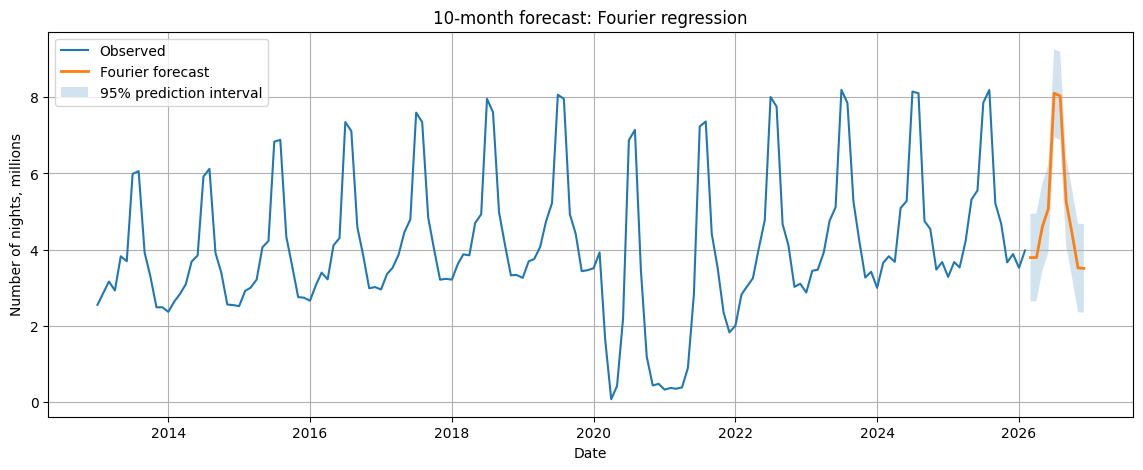

In [61]:
plt.figure(figsize=(14, 5))

plt.plot(y.index, y / 1_000_000, label="Observed")
plt.plot(
    fourier_forecast.index,
    fourier_forecast["mean"] / 1_000_000,
    label="Fourier forecast",
    linewidth=2
)

plt.fill_between(
    fourier_forecast.index,
    fourier_forecast["obs_ci_lower"] / 1_000_000,
    fourier_forecast["obs_ci_upper"] / 1_000_000,
    alpha=0.2,
    label="95% prediction interval"
)

plt.title("10-month forecast: Fourier regression")
plt.xlabel("Date")
plt.ylabel("Number of nights, millions")
plt.legend()
plt.grid(True)
plt.show()

#### SARIMA forecasting